# AWBW Stats Aggregator Examples

In [1]:
from matplotlib import pyplot as plt

from awbw_stats_aggregator import (
    get_completed_games,
    player_stats,
    win_rate_matrix,
    team_win_rates,
    team_elo,
    team_combo_elo,
)
from awbw_stats_aggregator.stats import BASE_TEAM_ELO

plt.rcParams.update({"figure.dpi": 150})

# Extract all games from a player

In [2]:
USERNAME = "ptMaV"
MAX_PAGES = 200  # adjust to balance runtime vs. data volume

games = get_completed_games(USERNAME, max_pages=MAX_PAGES)
print(f"Fetched {len(games)} games")

Fetched 57 games


In [3]:
opponents = ["mcxlog", "giogiotto", "diogofalso"]

head_to_head = player_stats(games, USERNAME, opponents=opponents, min_days=2)
head_to_head

,player,opponent,matches,wins,losses,draws,win_rate
0,ptMaV,mcxlog,16,6,10,0,0.375000
1,ptMaV,giogiotto,22,7,15,0,0.318182
2,ptMaV,diogofalso,23,10,13,0,0.434783


## Full Win-Rate Matrix

Build a symmetric matrix of win rates for a larger set of players and visualize it as a heatmap table.


In [4]:
players = ["ptMaV", "mcxlog", "giogiotto", "diogofalso"]
matrix = win_rate_matrix(games, players, min_days=2)
matrix

,ptMaV,mcxlog,giogiotto,diogofalso
ptMaV,NaN,0.375000,0.318182,0.434783
mcxlog,0.500000,NaN,0.375000,0.476190
giogiotto,0.681818,0.541667,NaN,0.588235
diogofalso,0.565217,0.476190,0.352941,NaN


# Team win rates

Produce all 2v2 team win rates for a list of players

In [5]:
players = ["ptMaV", "mcxlog", "giogiotto", "diogofalso"]
team_win_rates(games, players, team_size=2, min_days=2)

,team_a,team_b,matches,team_a_wins,team_b_wins,draws,team_a_win_rate,team_b_win_rate,draw_rate
0,ptMaV & diogofalso,mcxlog & giogiotto,7,1,6,0,0.142857,0.857143,0.0
1,ptMaV & giogiotto,mcxlog & diogofalso,9,5,4,0,0.555556,0.444444,0.0
2,ptMaV & mcxlog,giogiotto & diogofalso,14,5,9,0,0.357143,0.642857,0.0


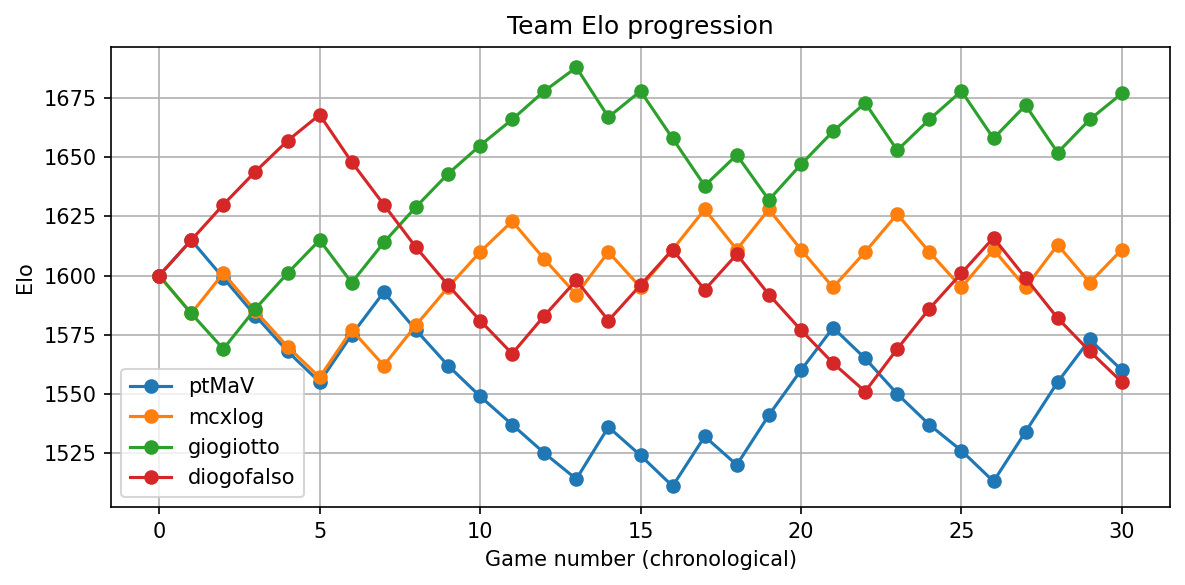

In [6]:
# Team Elo tracking and per-game evolution plot (AoE2-style)
elo_df = team_elo(
    games,
    players,
    team_size=2,
    min_days=2,
    k_factor=32,
    scale=400,
    round_mode="nearest",
)
elo_df.tail()

# Plot Elo progression per player (include starting Elo before first game)
fig, ax = plt.subplots(figsize=(8, 4))
for player in players:
    series = elo_df[elo_df["player"] == player].sort_values(
        ["ended_on", "day", "game_id"]
    )
    if series.empty:
        continue
    x_vals = list(range(len(series) + 1))  # start at game 0
    y_vals = [BASE_TEAM_ELO] + series["rating_after"].tolist()
    ax.plot(
        x_vals,
        y_vals,
        marker="o",
        label=player,
    )
ax.set_xlabel("Game number (chronological)")
ax.set_ylabel("Elo")
ax.set_title("Team Elo progression")
ax.legend()
ax.grid(True)
plt.tight_layout()


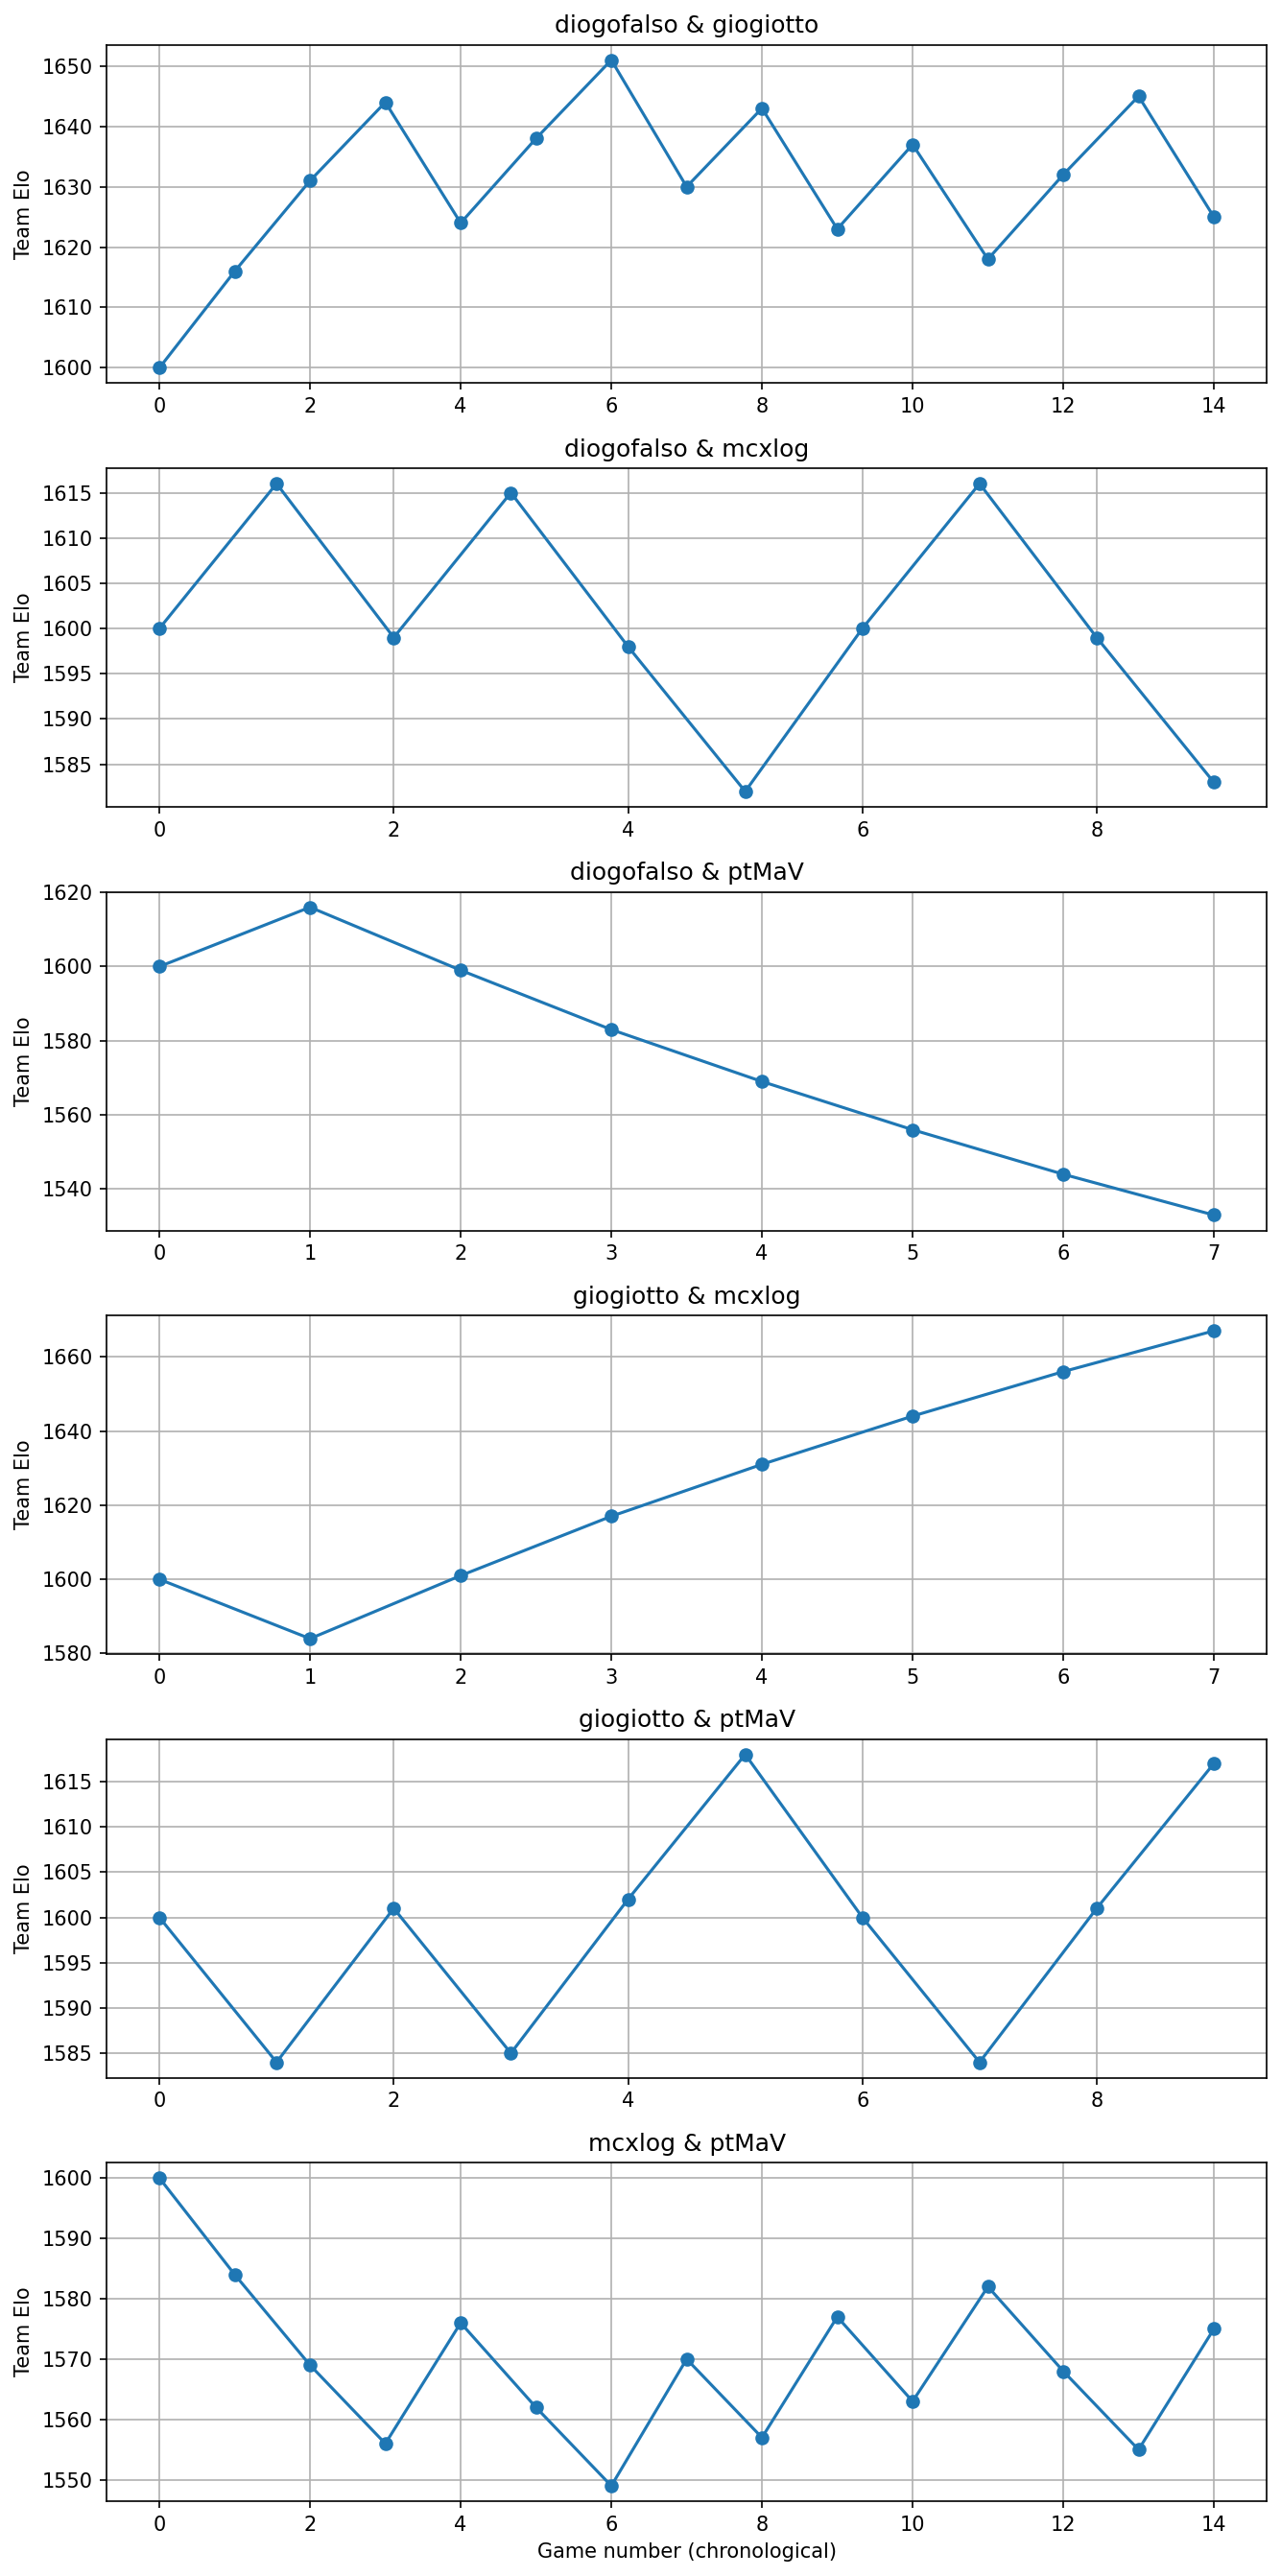

In [7]:
# Team-level Elo (combinations) progression (AoE2-style)
team_elo_df = team_combo_elo(
    games,
    players,
    team_size=2,
    min_days=2,
    k_factor=32,
    scale=400,
    round_mode="nearest",
)
team_elo_df.tail()

# One subplot per team to handle differing game counts
by_team = (
    team_elo_df.sort_values(["ended_on", "day", "game_id"])
    .groupby("team")
)
team_labels = list(by_team.groups.keys())
num_teams = len(team_labels)
if num_teams == 0:
    raise ValueError("No team matchups found for the provided filters")

fig, axes = plt.subplots(num_teams, 1, figsize=(9, 3 * num_teams), sharex=False)
if num_teams == 1:
    axes = [axes]

for ax, team_label in zip(axes, team_labels):
    series = by_team.get_group(team_label)
    x_vals = list(range(len(series) + 1))
    y_vals = [BASE_TEAM_ELO] + series["rating_after"].tolist()
    ax.plot(x_vals, y_vals, marker="o")
    ax.set_ylabel("Team Elo")
    ax.set_title(team_label)
    ax.grid(True)

axes[-1].set_xlabel("Game number (chronological)")
# fig.suptitle("Team Elo progression (team combinations)")
fig.tight_layout()


In [11]:
# Latest team Elo table
latest_team_elo = (
    team_elo_df.sort_values(["ended_on", "day", "game_id"])
    .groupby("team", as_index=False)
    .tail(1)
    .sort_values("rating_after", ascending=False)
    [["team", "rating_after"]]
    .reset_index(drop=True)
)
latest_team_elo


,team,rating_after
0,giogiotto & mcxlog,1667.0
1,diogofalso & giogiotto,1625.0
2,giogiotto & ptMaV,1617.0
3,diogofalso & mcxlog,1583.0
4,mcxlog & ptMaV,1575.0
5,diogofalso & ptMaV,1533.0


In [13]:
# Latest player Elo table
latest_player_elo = (
    elo_df.sort_values(["ended_on", "day", "game_id"])
    .groupby("player", as_index=False)
    .tail(1)
    .sort_values("rating_after", ascending=False)
    [["player", "rating_after"]]
    .reset_index(drop=True)
)
latest_player_elo


,player,rating_after
0,giogiotto,1677.0
1,mcxlog,1611.0
2,ptMaV,1560.0
3,diogofalso,1555.0
